# Практикум: Базовая статистика для Data Analytics / BI

Этот ноутбук содержит 5 экспресс-задач.
В каждой задаче уже сгенерированы синтетические данные. Ваша цель — дописать код в местах, отмеченных `TODO`, и ответить на бизнес-вопросы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для графиков
sns.set_theme(style="whitegrid")
np.random.seed(42)

## Тема 1. Описательная статистика и распределения
**Контекст:** Вы анализируете чеки покупок за день. Большинство покупок — это кофе и выпечка, но один клиент купил профессиональную кофемашину.

In [2]:
# Генерация данных: 19 чеков от 100 до 500 руб. и 1 чек на 100 000 руб.
normal_checks = np.random.randint(100, 500, 19)
outlier_check = np.array([100000])
checks = np.concatenate([normal_checks, outlier_check])
df_checks = pd.DataFrame({'amount_rub': checks})

In [5]:
# TODO: Рассчитайте среднее арифметическое, медиану и моду для столбца amount_rub
mean_val = df_checks['amount_rub'].mean()
median_val = df_checks['amount_rub'].median()
mode_val = df_checks['amount_rub'].mode()

print(f"Среднее: {mean_val}")
print(f"Медиана: {median_val}")
print(f"Мода: {mode_val}")

Среднее: 5271.35
Медиана: 250.0
Мода: 0    202
Name: amount_rub, dtype: int32


**Бизнес-вопрос (Тема 1):**
*TODO: Напишите здесь, какое из этих значений лучше вывести на главный экран дашборда интернет-магазина как "Типичный чек за день" и почему?*
В данном случае на главный экран дашборда в качестве "Типичного чека за день" следует вывести медианное значение. Среднее крайне чувствительная к выбросам величина, поэтому такие значения как 100000 будут сильно увеличивать среднее значение и не будет отражать реальную ситуацию на наших данных. Мода крайне нестабильная величина, в один день несколько людей могу купить продукции на одинаковую стоимость, в другой у всех клиентов может быть разный чек - это также не будет отражать реальную ситуацию. Медиана является идеальной мерой для анализа данных такого числового типа, т.к. она делит наши данные ровно 50 на 50, игнорирует выбросы. Благодаря медиане, мы может понимать, что половина клиентов потратила больше 250, половина меньше.

## Тема 2. Выбросы: Поиск и обработка (Метод IQR)
**Контекст:** Логистический сервис анализирует время доставки (в минутах). В базу попали ошибочные значения (баги трекинга). Нужно отфильтровать аномалии.

In [8]:
# Генерация данных: 1000 нормальных доставок (30-90 мин) + 20 багов (например, -999 мин или 5000 мин)
delivery_times = np.concatenate([
    np.random.normal(60, 15, 1000),
    [-999]*10,
    [5000]*10
])
df_delivery = pd.DataFrame({'duration_min': delivery_times})

In [11]:
# TODO 1: Найдите Q1 (25-й перцентиль) и Q3 (75-й перцентиль)
q1 = np.percentile(df_delivery['duration_min'], 25)
q3 = np.percentile(df_delivery['duration_min'], 75)

# TODO 2: Рассчитайте межквартильный размах (IQR)
iqr = q3 - q1

# TODO 3: Рассчитайте нижнюю и верхнюю границы (Q1 - 1.5*IQR и Q3 + 1.5*IQR)
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

# TODO 4: Отфильтруйте df_delivery, оставив только нормальные значения
df_clean = df_delivery[(df_delivery['duration_min'] > lower_bound) & (df_delivery['duration_min'] < upper_bound)]

# Расчет процента отсеянных строк
dropped_percent = (1 - len(df_clean) / len(df_delivery)) * 100
print(f"Отсеяно выбросов: {dropped_percent:.1f}%")

Отсеяно выбросов: 2.4%


## Тема 3. Корреляция и причинно-следственные связи
**Контекст:** Вы изучаете статистику городских пожаров. Построен график зависимости между количеством вызванных пожарных машин и суммой ущерба.

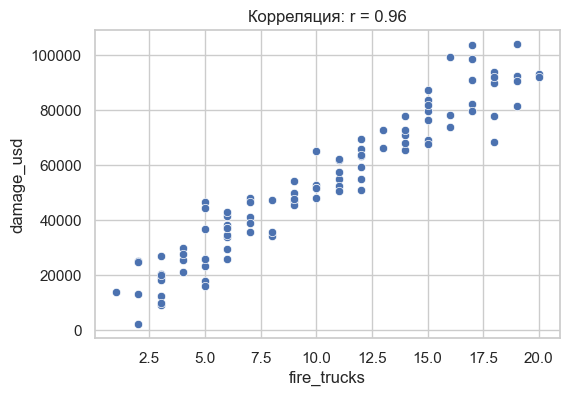

,fire_trucks,damage_usd
0,19,92476.808564
1,18,89805.737676
2,6,29320.420283
3,5,25677.887963
4,6,25885.743942
...,...,...
95,9,47564.937212
96,18,68512.717556
97,6,36994.538703
98,1,13852.523496


In [ ]:
# Синтетические данные: Размер пожара (скрытый фактор - confounder) влияет и на число машин, и на ущерб
fire_severity = np.random.uniform(1, 10, 100)
fire_trucks = (fire_severity * 2 + np.random.normal(0, 1, 100)).astype(int)
damage_usd = fire_severity * 10000 + np.random.normal(0, 5000, 100)

df_fires = pd.DataFrame({
    'fire_trucks': fire_trucks,
    'damage_usd': damage_usd
})

# Построение графика
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_fires, x='fire_trucks', y='damage_usd')
plt.title(f"Корреляция: r = {df_fires.corr().iloc[0,1]:.2f}")
plt.show()

**Бизнес-вопрос (Тема 3):**
Корреляция Пирсона показывает сильную прямую связь ($r > 0.9$).
*TODO: Верно ли утверждение «Чем больше пожарных машин приезжает, тем больший ущерб они наносят»? Какая скрытая переменная (Confounder) здесь присутствует?*
Нет, такое утверждение не будет верно. В данном случае можно наблюдать влияние третьей скрытой переменной, а именно - "Масштаб происшествия (пожара)". Чем больше пожар по размеру, тем больше приезжает пожарных машин и тем больше денег требуется на восстановление. Корреляция показывает нам, происходит ли изменение одной величины вместе с другой, но никак не причину, что из-за изменения одной величины изменяется другая.

## Тема 4. Когортный анализ (Retention)
**Контекст:** Маркетинг предоставил готовую матрицу удержания (Retention Matrix) по месяцам. Вам нужно сделать выводы без написания кода.

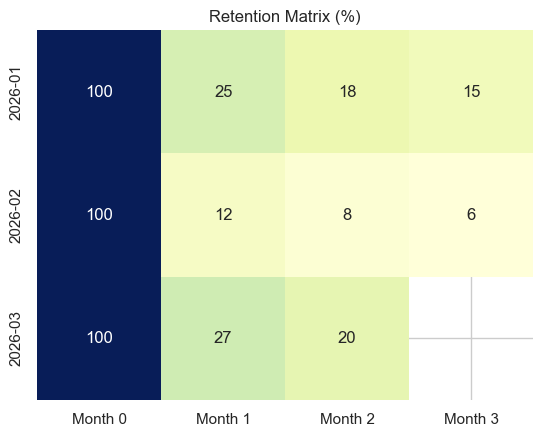

In [30]:
# Готовая матрица удержания в виде DataFrame
retention_matrix = pd.DataFrame({
    'Month 0': [100, 100, 100],
    'Month 1': [25, 12, 27],
    'Month 2': [18, 8, 20],
    'Month 3': [15, 6, np.nan]
}, index=['2026-01', '2026-02', '2026-03'])

# Тепловая карта для наглядности
sns.heatmap(retention_matrix, annot=True, fmt='g', cmap='YlGnBu', cbar=False)
plt.title("Retention Matrix (%)")
plt.show()

**Бизнес-вопросы (Тема 4):**
*TODO:*
1. *В какой когорте произошел резкий провал качества трафика (или сбой в продукте)?*
Резкий провал произошел в февральской когорте ("2026-02"). Можно увидеть, что по сравнению с другими когортами % удержания пользователей на 1 месяц составляет 12%, на 2 месяц - 8%, на 3 месяц - 6%. Это значительно хуже, чем у январской, и еще хуже, чем у мартовской когорт.
2. *Какой процент пользователей январской когорты ('2026-01') вернулся на 2-й месяц (Month 2)?*
На второй месяц вернулся 18% пользователей январской когорты

## Тема 5. RFM-анализ и сегментация
**Контекст:** Вы посчитали скоры R, F, M (от 1 до 3) для небольшой выборки клиентов. Теперь нужно разметить клиентов по бизнес-сегментам.

In [35]:
# Данные о клиентах (уже рассчитанные квантили 1-3)
# R: 3 = недавняя покупка. F: 3 = частые покупки. M: 3 = высокий чек.
df_rfm = pd.DataFrame({
    'client_id': [101, 102, 103, 104, 105],
    'R': [3, 1, 2, 1, 3],
    'F': [3, 3, 2, 1, 2],
    'M': [3, 2, 2, 1, 1]
})
df_rfm

,client_id,R,F,M
0,101,3,3,3
1,102,1,3,2
2,103,2,2,2
3,104,1,1,1
4,105,3,2,1


In [36]:
# TODO: Напишите функцию категоризации или используйте np.select / df.apply
def assign_segment(row):
    # Логика:
    # 1. Если R=3, F=3, M=3 -> 'Champion'
    # 2. Если R<=1 и F>=2 -> 'At Risk'
    # 3. Все остальные -> 'Regular'

    # --- ВАШ КОД НИЖЕ ---
    if row['R'] == 3 and row['F'] == 3 and row['M'] == 3:
        return 'Champion'
    elif row['R'] <= 1 and row['F'] >= 2:
        return 'At Risk'
    else:
        return 'Regular'
    # --------------------

df_rfm['Segment'] = df_rfm.apply(assign_segment, axis=1)
display(df_rfm)

,client_id,R,F,M,Segment
0,101,3,3,3,Champion
1,102,1,3,2,At Risk
2,103,2,2,2,Regular
3,104,1,1,1,Regular
4,105,3,2,1,Regular
